# Домашнее задание №2

Тема "Доверительные интервалы"

Общие положения:
- Макс кол-во баллов за ДЗ - 25 баллов
- Качество оформления и кода играет роль

Список заданий:
1.



In [ ]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use('ggplot')
%matplotlib inline

In [ ]:
# задаём стандартное нормальное распределение
norm_distr = stats.norm(loc=0, scale=1)

# рассчитываем квантиль по заданному уровню значимости
alpha = 0.05
z = norm_distr.ppf(alpha/2)
print(z)

-1.9599639845400545


In [ ]:
def get_t_quantile(n, alpha):
  distr = stats.t(n - 1)
  return distr.ppf(1 - alpha)

In [ ]:
def get_z_quantile(alpha):
  distr = stats.norm(loc=0, scale=1)
  return distr.ppf(1 - alpha)

In [ ]:
def get_asymp_interval(mu, sigma, n, alpha):
  coef = get_z_quantile(alpha / 2) * sigma / np.sqrt(n)
  return mu - coef, mu + coef

In [ ]:
def get_exact_interval(mu_sample, sigma_sample, n, alpha):
  coef = get_t_quantile(n, alpha / 2) * sigma_sample / np.sqrt(n)
  return mu_sample - coef, mu_sample + coef

In [ ]:
def get_part_interval(p, n, alpha):
  coef = get_z_quantile(alpha / 2) * np.sqrt(p * (1-p) / n)
  return p - coef, p + coef

## Задание 1  
Компания утверждает, что длина шнурков в партии обуви имеет среднее значение 120 см, и стандартное отклонение в партии точно известно и составляет 5 см. Из выборки 25 шнурков было получено среднее значение длины 122 см. Найдите 99%-ый доверительный интервал для среднего значения длины шнурков (1 балл)

In [ ]:
sigma = 5
n = 25
mu = 122
alpha = 0.01

bottom, top = get_asymp_interval(mu, sigma, n, alpha)

print(f'Асимптотический доверительный интервал: [{bottom:.2f}, {top:.2f}]')

Асимптотический доверительный интервал: [119.42, 124.58]


##Задание 2
Компания исследует среднее время выполнения заказа курьерской службой. Было случайным образом выбрано 10 заказов, для которых среднее время доставки составило 45 минут, а выборочная дисперсия — 9 минут. Постройте 95%-ый доверительный интервал для среднего времени доставки заказа (1 балл)

In [ ]:
sigma = 9
n = 10
mu = 45
alpha = 0.05

bottom, top = get_exact_interval(mu, sigma, n, alpha)

print(f'Точный доверительный интервал: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал: [38.56, 51.44]


## Задание 3
Интернет-магазин хочет определить долю пользователей, которые возвращаются для повторной покупки в течение месяца после первой покупки. Для этого он проанализировал выборку из 800 клиентов, и оказалось, что 240 из них сделали повторную покупку в течение месяца. Необходимо определить 95% доверительный интервал для истинной доли клиентов, которые возвращаются для повторной покупки в течение этого времени (1 балл)


In [ ]:
p = 240 / 800
n = 800
alpha = 0.05

bottom, top = get_part_interval(p, n, alpha)

print(f'Доверительный интервал для доли: [{bottom:.2f}, {top:.2f}]')

Доверительный интервал для доли: [0.27, 0.33]


## Задание 4
Два студента Тимофей и Пётр решают задачи из учебника по статистике, каждый со своей усердностью λ (количество решенных задач в день).
Тимофей считает себя более усердным студентом. Необходимо построить доверительный для разности λ1 - λ2 и проверить, правда ли это.
Студенты решают задачи независимо друг от друга (1 балл)

In [ ]:
a = [7, 5, 2, 8, 4, 9, 2, 6, 6, 7] # Тимофей
b = [3, 3, 3, 9, 9, 2, 2, 2, 2, 9] # Пётр

diff = np.array(b) - np.array(a)

mu = np.mean(diff)
sigma = np.std(diff, ddof=1)
alpha = 0.05
n = len(a)

bottom, top = get_asymp_interval(mu, sigma, n, alpha)

contains_zero = bottom * top <= 0
zero_str = 'Интервал включает ноль, поэтому нельзя сказать, кто более усерден.'
non_zero_str = 'Вероятно, Тимофей усерднее.' if bottom > 0 else 'Вероятно, Пётр усерднее.'

print(f'Доверительный интервал для доли: [{bottom:.2f}, {top:.2f}]. {zero_str if contains_zero else non_zero_str}')

Доверительный интервал для доли: [-3.44, 1.04]. Интервал включает ноль, поэтому нельзя сказать, кто более усерден.


## Задания 5-8 (5 баллов всего)

In [ ]:
!curl -O https://raw.githubusercontent.com/practical-jupyter/sample-data/refs/heads/master/anime/anime.csv >> anime.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  778k  100  778k    0     0  1374k      0 --:--:-- --:--:-- --:--:-- 1375k


Описание датафрейма:
- `anime_id` - ID
- `name` - название
- `genre` - жанр (строка с пречисление через запятую)
- `type` - формат
- `episodes` - кол-во эпизодов
- `rating` - средний рейтинг
- `members` - кол-во смотрящих

In [ ]:
df_anime = pd.read_csv('anime.csv')
df_anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  10486 non-null  int64  
 1   name      10486 non-null  object 
 2   genre     10424 non-null  object 
 3   type      10463 non-null  object 
 4   episodes  10486 non-null  object 
 5   rating    10275 non-null  float64
 6   members   10486 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 573.6+ KB


## 5. Постройте доверительный интервал для среднего рейтинга по всем аниме (1 балл)

In [ ]:
sigma = df_anime['rating'].std(ddof=1)
mu = df_anime['rating'].mean()
n = df_anime['rating'].count()
alpha = 0.05

bottom, top = get_exact_interval(mu, sigma, n, alpha)

print(f'Точный доверительный интервал: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал: [6.47, 6.51]


## 6. Постройте доверительные интервалы для средних рейтингов по жанрам  (1 балл)

Разобьем аниме по жанрам:

In [ ]:
df_splitted_genres = df_anime.copy()
df_splitted_genres['genre'] = df_splitted_genres['genre'].str.split(',')
df_splitted_genres = df_splitted_genres.explode('genre')
df_splitted_genres['genre'] = df_splitted_genres['genre'].str.strip()
df_splitted_genres.dropna(subset=['genre'], inplace=True)
df_splitted_genres.reset_index(drop=True, inplace=True)
df_splitted_genres.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,Drama,Movie,1,9.37,200630
1,32281,Kimi no Na wa.,Romance,Movie,1,9.37,200630
2,32281,Kimi no Na wa.,School,Movie,1,9.37,200630
3,32281,Kimi no Na wa.,Supernatural,Movie,1,9.37,200630
4,5114,Fullmetal Alchemist: Brotherhood,Action,TV,64,9.26,793665


Найдем доверительные интервалы:

In [ ]:
alpha = 0.05
genres = df_splitted_genres['genre'].unique()

for genre in genres:
  df_genre = df_splitted_genres[df_splitted_genres['genre'] == genre]
  df_genre_rating = df_genre['rating'].dropna()
  sigma = df_genre_rating.std(ddof=1)
  mu = df_genre_rating.mean()
  n = df_genre_rating.count()
  if n < 2:
    print(f'Слишком мало наблюдений для жанра {genre} (0 или 1), нельзя построить доверительный интервал.')
    continue
  bottom, top = get_exact_interval(mu, sigma, n, alpha)
  print(f'Точный доверительный интервал для жанра {genre}: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал для жанра Drama: [6.95, 7.03]
Точный доверительный интервал для жанра Romance: [7.02, 7.11]
Точный доверительный интервал для жанра School: [6.96, 7.07]
Точный доверительный интервал для жанра Supernatural: [6.97, 7.10]
Точный доверительный интервал для жанра Action: [6.77, 6.85]
Точный доверительный интервал для жанра Adventure: [6.71, 6.78]
Точный доверительный интервал для жанра Fantasy: [6.64, 6.72]
Точный доверительный интервал для жанра Magic: [6.76, 6.88]
Точный доверительный интервал для жанра Military: [6.93, 7.11]
Точный доверительный интервал для жанра Shounen: [7.02, 7.10]
Точный доверительный интервал для жанра Comedy: [6.59, 6.65]
Точный доверительный интервал для жанра Historical: [6.69, 6.83]
Точный доверительный интервал для жанра Parody: [6.44, 6.67]
Точный доверительный интервал для жанра Samurai: [6.66, 7.03]
Точный доверительный интервал для жанра Sci-Fi: [6.67, 6.75]
Точный доверительный интервал для жанра Thriller: [7.15, 7.62]
Точны

## 7. Постройте доверительные интервалы среднего рейтинга по типам аниме (1 балл)

In [ ]:
alpha = 0.05

df_types = df_anime.copy()
df_types.dropna(subset=['type'], inplace=True)
types = df_types['type'].unique()

for _type in types:
  df_type = df_types[df_types['type'] == _type]
  df_type_rating = df_type['rating'].dropna()
  sigma = df_type_rating.std(ddof=1)
  mu = df_type_rating.mean()
  n = df_type_rating.count()
  if n < 2:
    print(f'Слишком мало наблюдений для типа {_type} (0 или 1), нельзя построить доверительный интервал.')
    continue
  bottom, top = get_exact_interval(mu, sigma, n, alpha)
  print(f'Точный доверительный интервал для типа {_type}: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал для типа Movie: [6.26, 6.36]
Точный доверительный интервал для типа TV: [6.87, 6.93]
Точный доверительный интервал для типа OVA: [6.43, 6.52]
Точный доверительный интервал для типа Special: [6.48, 6.57]
Точный доверительный интервал для типа Music: [5.50, 5.67]
Точный доверительный интервал для типа ONA: [5.55, 5.72]


## 8. По доверительным интервалам для episodes, rating и members оцените количество аномалий (2 балла)

Предобработаем столбец `episodes`:

Выведем описание таблицы:

In [ ]:
df_anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  10486 non-null  int64  
 1   name      10486 non-null  object 
 2   genre     10424 non-null  object 
 3   type      10463 non-null  object 
 4   episodes  10486 non-null  object 
 5   rating    10275 non-null  float64
 6   members   10486 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 573.6+ KB


Видим, что столбец `episodes` имеет тип `object`. Проверим, можно ли привести его к `int64`:

In [ ]:
errors = set()
for i in df_anime['episodes'].unique():
    try:
        ii = int(i)
    except:
        errors.add(i)

errors

{'Unknown'}

Видим, что существует значение, которое нельзя привести к `int64`. Заменим его на -1 и приведем типы:

In [ ]:
df_anime['episodes'] = df_anime['episodes'].replace('Unknown', '-1').astype(np.int64)

Посчитаем доверительные интервалы по столбцам `episodes`, `rating`, `members`:

In [ ]:
def print_col_stat(col_name, bottom, top, anom_count, anom_percentage):
  print(f'Доверительный интервал для колонки {col_name}: [{bottom:.2f}, {top:.2f}]')
  print(f'Количество аномалий для для колонки {col_name}: {anom_count}, что составляет {anom_percentage:.2f}% от общего числа аниме.')

In [ ]:
alpha = 0.05

df_episodes = df_anime['episodes'].dropna()
df_rating = df_anime['rating'].dropna()
df_members = df_anime['members'].dropna()

bottom_episodes, top_episodes = get_exact_interval(df_episodes.mean(), df_episodes.std(ddof=1), df_episodes.count(), alpha)
bottom_rating, top_rating = get_exact_interval(df_rating.mean(), df_rating.std(ddof=1), df_rating.count(), alpha)
bottom_members, top_members = get_exact_interval(df_members.mean(), df_members.std(ddof=1), df_members.count(), alpha)

anom_episodes = df_anime.query('episodes < @bottom_episodes or episodes > @top_episodes')
anom_rating = df_anime.query('rating < @bottom_rating or rating > @top_rating')
anom_members = df_anime.query('members < @bottom_members or members > @top_members')

total_count = df_anime['anime_id'].count()

print_col_stat('episodes', bottom_episodes, top_episodes, anom_episodes['anime_id'].count(), anom_episodes['anime_id'].count() / total_count * 100)
print_col_stat('rating', bottom_rating, top_rating, anom_rating['anime_id'].count(), anom_rating['anime_id'].count() / total_count * 100)
print_col_stat('members', bottom_members, top_members, anom_members['anime_id'].count(), anom_members['anime_id'].count() / total_count * 100)

Доверительный интервал для колонки episodes: [12.44, 14.35]
Количество аномалий для для колонки episodes: 9923, что составляет 94.63% от общего числа аниме.
Доверительный интервал для колонки rating: [6.47, 6.51]
Количество аномалий для для колонки rating: 10085, что составляет 96.18% от общего числа аниме.
Доверительный интервал для колонки members: [17396.25, 19561.60]
Количество аномалий для для колонки members: 10376, что составляет 98.95% от общего числа аниме.


Возможно, такие высокие значения получены из-за того, что распределения не являются нормальными.

## Задания 9-15. Продуктовые метрики (16 баллов всего)

In [ ]:
!curl -O https://raw.githubusercontent.com/alina-zhu/datasets/refs/heads/master/customer_shopping_data.csv >> customer_shopping_data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6410k  100 6410k    0     0  6991k      0 --:--:-- --:--:-- --:--:-- 6990k


Описание датафрейма:
- `invoice_no` - номер чека
- `customer_id` - id клиента
- `gender` - пол клиента
- `age` - возраст клиента
- `category` - категория товара
- `quantity` - количество единиц товаров в чеке
- `price` - цена товара
- `payment_method` - метод оплаты
- `invoice_date` - дата покупки


In [ ]:
df = pd.read_csv('customer_shopping_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 6.8+ MB


In [ ]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date
0,I138884,upeszhn26j,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05
1,I317333,nyyoavbmge,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12
2,I127801,iksbmqrtj0,Male,20,Clothing,1,300.08,Cash,2021-11-09
3,I173702,zfhc107gzu,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16
4,I337046,diwrquryyt,Female,53,Books,4,60.60,Cash,2021-10-24


## 9. Посчитайте доверительный интервал для среднего возраста покупателей (1 балл)

In [ ]:
data = df['age'].dropna()

sigma = data.std(ddof=1)
mu = data.mean()
n = data.count()
alpha = 0.05

bottom, top = get_exact_interval(mu, sigma, n, alpha)

print(f'Точный доверительный интервал для возраста: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал для возраста: [43.33, 43.52]


## 10. Посчитайте доверительные интервалы для среднего чека в каждой категории (1 балл)

Проверим, есть ли такие чеки, в которых встречается больше одной категории:

In [ ]:
df['invoice_no'].duplicated().sum()

0

Таких чеков нет, в одном чеке одна категория товаров. Посчитаем доверительные интервалы:

In [ ]:
alpha = 0.05

df_categories = df.copy()
df_categories.dropna(subset=['category'], inplace=True)
df_categories['total_price'] = df_categories['quantity'] * df_categories['price']

categories = df_categories['category'].unique()

for _category in categories:
  df_category = df_categories[df_categories['category'] == _category]
  price_category = df_category['total_price'].dropna()
  sigma = price_category.std(ddof=1)
  mu = price_category.mean()
  n = price_category.count()
  if n < 2:
    print(f'Слишком мало наблюдений для категории {_category} (0 или 1), нельзя построить доверительный интервал среднего чека.')
    continue
  bottom, top = get_exact_interval(mu, sigma, n, alpha)
  print(f'Точный доверительный интервал среднего чека для категории {_category}: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал среднего чека для категории Clothing: [3278.09, 3332.91]
Точный доверительный интервал среднего чека для категории Shoes: [6531.40, 6734.18]
Точный доверительный интервал среднего чека для категории Books: [163.88, 171.21]
Точный доверительный интервал среднего чека для категории Cosmetics: [444.33, 455.56]
Точный доверительный интервал среднего чека для категории Food & Beverage: [56.76, 58.23]
Точный доверительный интервал среднего чека для категории Toys: [388.61, 400.61]
Точный доверительный интервал среднего чека для категории Technology: [11330.16, 11833.31]
Точный доверительный интервал среднего чека для категории Souvenir: [124.38, 130.00]


## 11. Посчитайте доверительные интервалы для среднего чека для каждого типа оплаты (1 балл)

In [ ]:
alpha = 0.05

df_payment_methods = df.copy()
df_payment_methods.dropna(subset=['payment_method'], inplace=True)
df_payment_methods['total_price'] = df_payment_methods['quantity'] * df_payment_methods['price']

payment_methods = df_payment_methods['payment_method'].unique()

for _method in payment_methods:
  df_payment_method = df_payment_methods[df_payment_methods['payment_method'] == _method]
  price_method = df_payment_method['total_price'].dropna()
  sigma = price_method.std(ddof=1)
  mu = price_method.mean()
  n = price_method.count()
  if n < 2:
    print(f'Слишком мало наблюдений для типа оплаты {_method} (0 или 1), нельзя построить доверительный интервал среднего чека.')
    continue
  bottom, top = get_exact_interval(mu, sigma, n, alpha)
  print(f'Точный доверительный интервал среднего чека для типа оплаты {_method}: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал среднего чека для типа оплаты Credit Card: [2477.25, 2565.67]
Точный доверительный интервал среднего чека для типа оплаты Debit Card: [2461.67, 2578.07]
Точный доверительный интервал среднего чека для типа оплаты Cash: [2499.21, 2577.95]


## 12. Посчитайте доверительный интервал для среднего количества позиций в чеке (1 балл)

In [ ]:
data = df['quantity'].dropna()

sigma = data.std(ddof=1)
mu = data.mean()
n = data.count()
alpha = 0.05

bottom, top = get_exact_interval(mu, sigma, n, alpha)

print(f'Точный доверительный интервал для среднего количества позиций в чеке: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал для среднего количества позиций в чеке: [2.99, 3.01]


## 13. Посчитайте доверительный для среднего количества покупателей в день (1 балл)

In [ ]:
data = df.groupby('invoice_date')['customer_id'].count()

sigma = data.std(ddof=1)
mu = data.mean()
n = data.count()
alpha = 0.05

bottom, top = get_exact_interval(mu, sigma, n, alpha)

print(f'Точный доверительный интервал для среднего количества покупателей в день: [{bottom:.2f}, {top:.2f}]')

Точный доверительный интервал для среднего количества покупателей в день: [124.03, 125.55]




## 14. Посчитайте помесячный retention для пользователей и доверительные интервалы для него (6 баллов)
Day N Retention = (Users Day N / Users Day 0) * 100

1) Постройте график retention   
2) Добавьте на график область доверительного интервала для каждого месяца

Построим таблицу с количеством пользователей за день:

In [ ]:
data = df.groupby('invoice_date')['customer_id'].count()
df_day_counts = pd.DataFrame({'invoice_date':data.index, 'customers_count':data.values})
df_day_counts['invoice_date'] = pd.to_datetime(df_day_counts['invoice_date'], format='%Y-%m-%d')
df_day_counts.sort_values('invoice_date', ascending=True)
df_day_counts.head()

,invoice_date,customers_count
0,2021-01-01,105
1,2021-01-02,134
2,2021-01-03,137
3,2021-01-04,119
4,2021-01-05,120


Добавим retention:

In [ ]:
first_day_count = df_day_counts['customers_count'].iloc[0]
df_day_counts['retention'] = df_day_counts['customers_count'] / first_day_count * 100
df_day_counts.head()

,invoice_date,customers_count,retention
0,2021-01-01,105,100.000000
1,2021-01-02,134,127.619048
2,2021-01-03,137,130.476190
3,2021-01-04,119,113.333333
4,2021-01-05,120,114.285714


Построим таблицу с retention и его отклонением за месяц:

In [ ]:
df_day_counts['year'] = df_day_counts['invoice_date'].dt.year
df_day_counts['month'] = df_day_counts['invoice_date'].dt.month

customer_counts_month = df_day_counts.groupby(['year', 'month'])['retention'].agg(['mean', lambda x: np.std(x, ddof=1)])
df_month_counts = pd.DataFrame({'month':customer_counts_month.index, 'retention_mean':customer_counts_month['mean'], 'retention_std':customer_counts_month['<lambda_0>']})
df_month_counts['month'] = df_month_counts['month'].apply(lambda x : datetime(*(x + (1,))))
df_month_counts.reset_index(drop=True, inplace=True)
df_month_counts.head()

,month,retention_mean,retention_std
0,2021-01-01,117.818740,9.815204
1,2021-02-01,115.884354,7.849485
2,2021-03-01,117.142857,9.240222
3,2021-04-01,118.222222,10.186265
4,2021-05-01,118.218126,9.291588


Построим доверительный интервал:

In [ ]:
alpha = 0.05
n = df_month_counts['month'].count()

def get_bottom(mu, sigma):
  return get_exact_interval(mu, sigma, n, alpha)[0]

def get_top(mu, sigma):
  return get_exact_interval(mu, sigma, n, alpha)[1]

In [ ]:
df_month_counts['interval_bottom'] = df_month_counts[['retention_mean', 'retention_std']].apply(lambda x: get_bottom(x['retention_mean'], x['retention_std']), axis=1)
df_month_counts['interval_top'] = df_month_counts[['retention_mean', 'retention_std']].apply(lambda x: get_top(x['retention_mean'], x['retention_std']), axis=1)

df_month_counts.head()

,month,retention_mean,retention_std,interval_bottom,interval_top
0,2021-01-01,117.818740,9.815204,113.935975,121.701506
1,2021-02-01,115.884354,7.849485,112.779201,118.989507
2,2021-03-01,117.142857,9.240222,113.487547,120.798167
3,2021-04-01,118.222222,10.186265,114.192670,122.251775
4,2021-05-01,118.218126,9.291588,114.542496,121.893756


Построим график:

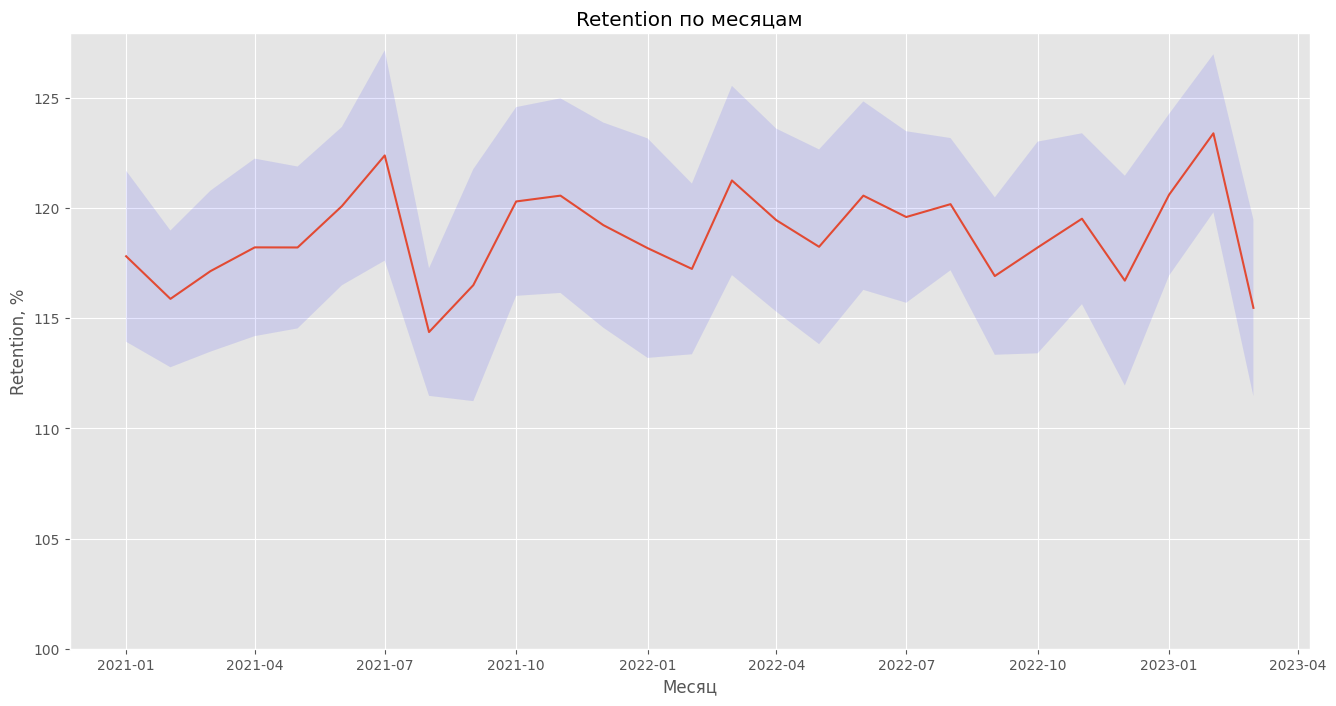

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.fill_between(df_month_counts['month'], df_month_counts['interval_bottom'], df_month_counts['interval_top'], alpha=0.1, facecolor='blue')
ax.plot(df_month_counts['month'], df_month_counts['retention_mean'])
ax.set_title('Retention по месяцам')
ax.set_ylabel('Retention, %')
ax.set_xlabel('Месяц')
ax.set_ylim(100)
plt.show()

## 15. Посчитайте средний доход с пользователя (ARPU) в каждом месяце и доверительные интервалы для него (5 баллов)
ARPU = Average Revenue Per User  
1) Постройте график ARPU для каждого месяца      
2) Добавьте на график область доверительного интервала для каждого месяца

Построим таблицу со средним чеком на пользователя:

In [ ]:
df['total_price'] = df['price'] * df['quantity']

data = df.groupby(['invoice_date', 'customer_id'])['total_price'].sum()
df_day_total = data.reset_index()
df_day_total.head()

,invoice_date,customer_id,total_price
0,2021-01-01,0l2a80ckqu,293.25
1,2021-01-01,17eu4wcv9u,2700.72
2,2021-01-01,1j0axds3df,5401.53
3,2021-01-01,1nlwvh4s7m,600.17
4,2021-01-01,3j4e2nv6mo,4801.28


In [ ]:
df_day_total_stats = df_day_total.groupby('invoice_date')['total_price'].agg('mean')
df_day_arpu = pd.DataFrame({'invoice_date':df_day_total_stats.index, 'arpu':df_day_total_stats.values})
df_day_arpu['invoice_date'] = pd.to_datetime(df_day_arpu['invoice_date'], format='%Y-%m-%d')
df_day_arpu.sort_values('invoice_date', ascending=True)
df_day_arpu.head()

,invoice_date,arpu
0,2021-01-01,2582.787238
1,2021-01-02,2266.112985
2,2021-01-03,2743.029124
3,2021-01-04,2390.859328
4,2021-01-05,2569.959000


Построим таблицу с arpu и его отклонением за месяц:

In [ ]:
df_day_arpu['year'] = df_day_arpu['invoice_date'].dt.year
df_day_arpu['month'] = df_day_arpu['invoice_date'].dt.month

arpu_month = df_day_arpu.groupby(['year', 'month'])['arpu'].agg(['mean', lambda x: np.std(x, ddof=1)])
df_month_arpu = pd.DataFrame({'month':arpu_month.index, 'arpu_mean':arpu_month['mean'], 'arpu_std':arpu_month['<lambda_0>']})
df_month_arpu['month'] = df_month_arpu['month'].apply(lambda x : datetime(*(x + (1,))))
df_month_arpu.reset_index(drop=True, inplace=True)
df_month_arpu.head()

,month,arpu_mean,arpu_std
0,2021-01-01,2524.555098,357.658954
1,2021-02-01,2582.397810,353.959085
2,2021-03-01,2487.687451,325.340528
3,2021-04-01,2527.898219,321.924377
4,2021-05-01,2543.565932,414.067201


Построим доверительный интервал:

In [ ]:
alpha = 0.05
n = df_month_arpu['month'].count()

def get_arpu_bottom(mu, sigma):
  return get_exact_interval(mu, sigma, n, alpha)[0]

def get_arpu_top(mu, sigma):
  return get_exact_interval(mu, sigma, n, alpha)[1]

In [ ]:
df_month_arpu['interval_bottom'] = df_month_arpu[['arpu_mean', 'arpu_std']].apply(lambda x: get_arpu_bottom(x['arpu_mean'], x['arpu_std']), axis=1)
df_month_arpu['interval_top'] = df_month_arpu[['arpu_mean', 'arpu_std']].apply(lambda x: get_arpu_top(x['arpu_mean'], x['arpu_std']), axis=1)

df_month_arpu.head()

,month,arpu_mean,arpu_std,interval_bottom,interval_top
0,2021-01-01,2524.555098,357.658954,2383.069928,2666.040268
1,2021-02-01,2582.397810,353.959085,2442.376259,2722.419360
2,2021-03-01,2487.687451,325.340528,2358.987024,2616.387877
3,2021-04-01,2527.898219,321.924377,2400.549176,2655.247261
4,2021-05-01,2543.565932,414.067201,2379.766402,2707.365461


Построим график:

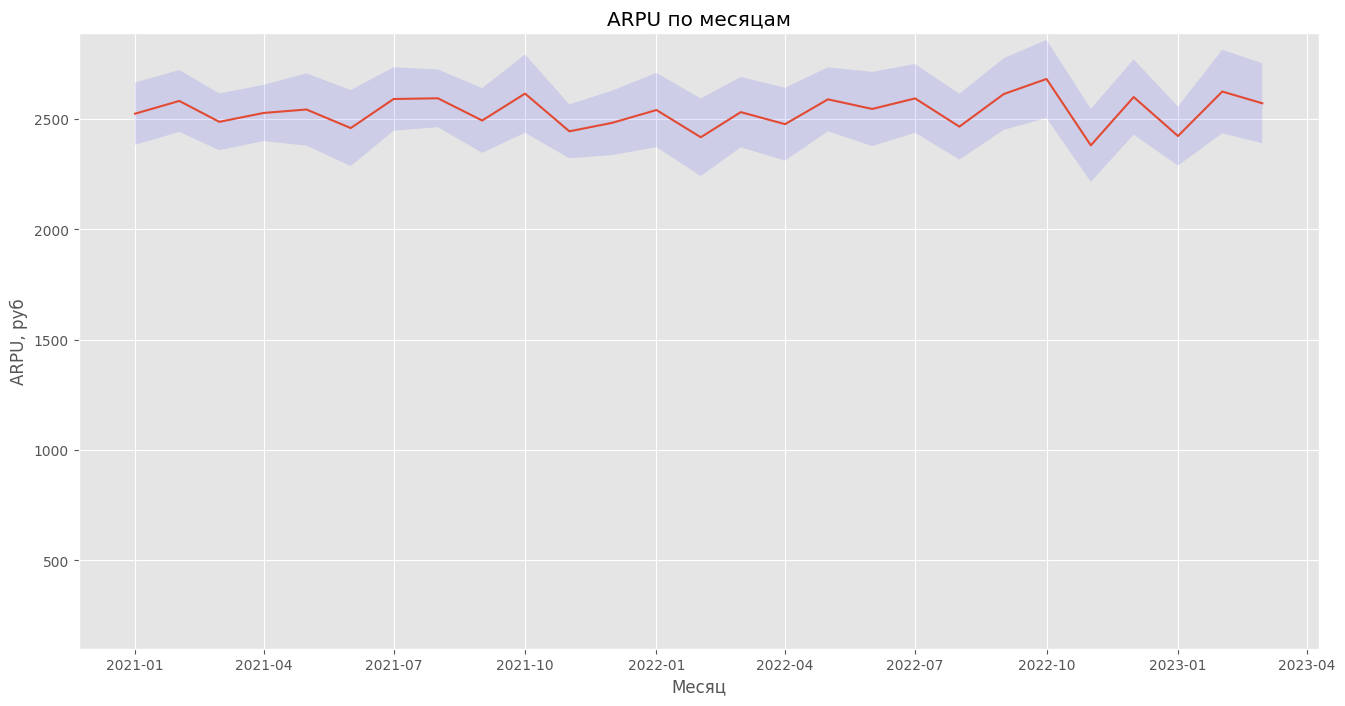

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.fill_between(df_month_arpu['month'], df_month_arpu['interval_bottom'], df_month_arpu['interval_top'], alpha=0.1, facecolor='blue')
ax.plot(df_month_arpu['month'], df_month_arpu['arpu_mean'])
ax.set_title('ARPU по месяцам')
ax.set_ylabel('ARPU, руб')
ax.set_xlabel('Месяц')
ax.set_ylim(100)
plt.show()